<a href="https://colab.research.google.com/github/Guava99/llm_journey/blob/main/miniproject_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA


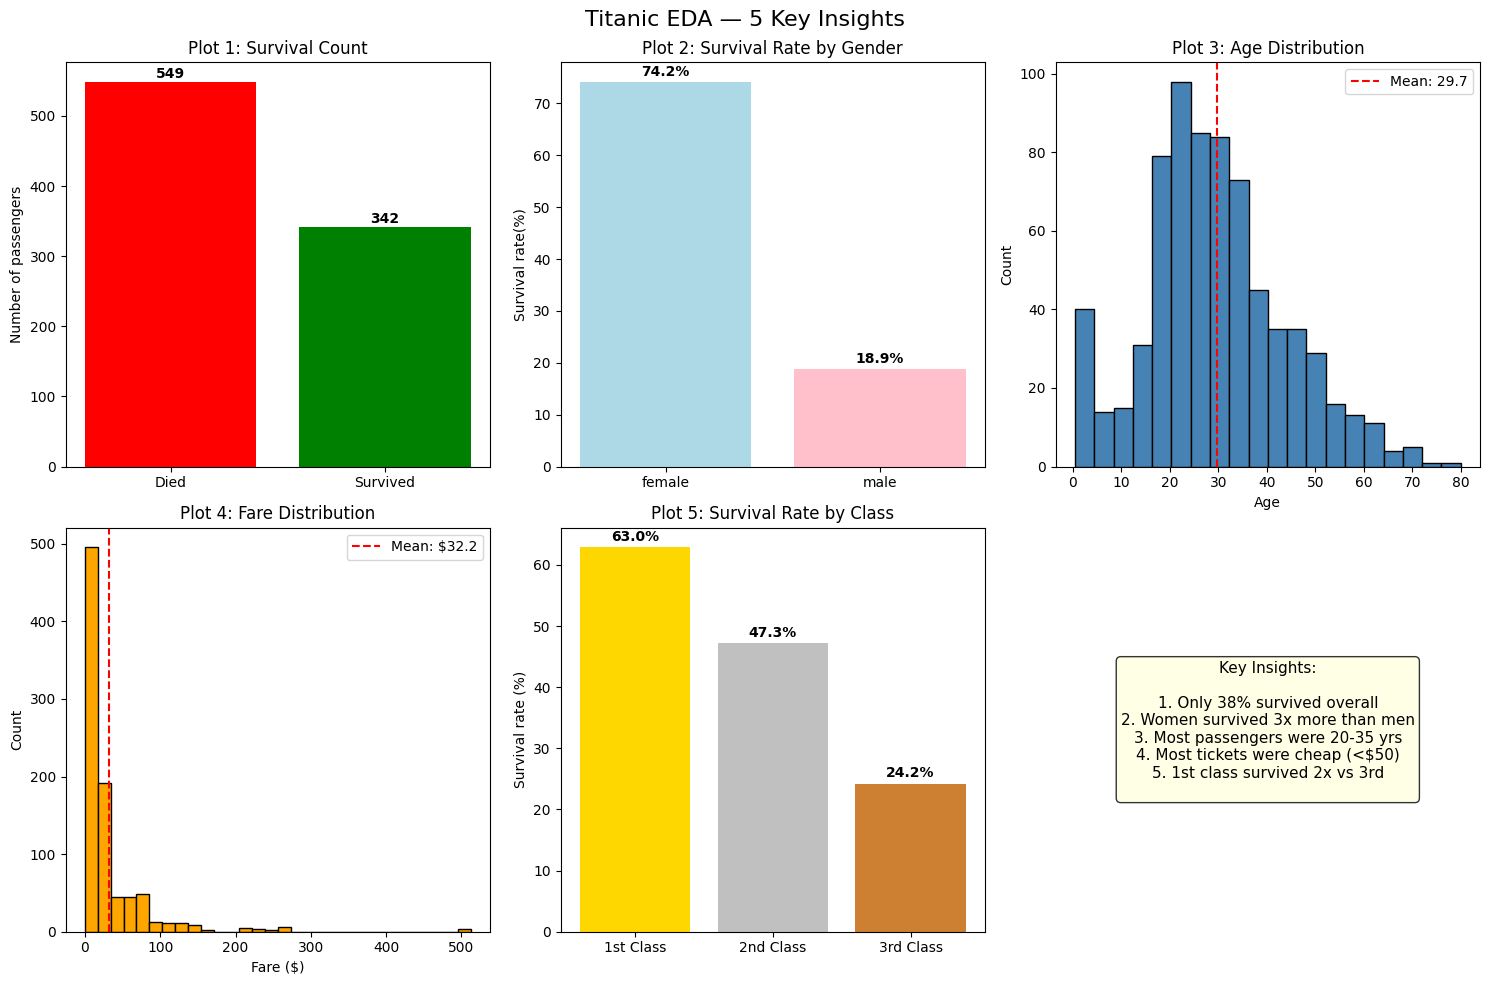

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#load Titanic dataset
df=sns.load_dataset('titanic')
#Basic checks
# print("Shape:",df.shape)
# print("\nColumns:",df.columns.tolist())
# print("\n Missing values: \n",df.isnull().sum())
# print("\nFirst 5 rows:\n",df.head())

# Create a 2x3 grid of subplots — 6 boxes to draw in
# figsize=(15,10) → width=15 inches, height=10 inches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Main title for the entire figure
fig.suptitle('Titanic EDA — 5 Key Insights', fontsize=16)

# ═══════════════════════════════════════════════════════
# PLOT 1 — How many survived vs died?
# ═══════════════════════════════════════════════════════

# Count how many 0s (died) and 1s (survived) in survived column
# Output: {0: 549, 1: 342}
survival_counts = df['survived'].value_counts()

# Draw bar chart in first box (row 0, col 0)
# x axis = Died/Survived labels, y axis = counts
axes[0,0].bar(['Died', 'Survived'],
               survival_counts.values,
               color=['red', 'green'])  # red=died, green=survived

axes[0,0].set_title('Plot 1: Survival Count')   # box title
axes[0,0].set_ylabel('Number of passengers')     # y axis label
for i, v in enumerate(survival_counts.values):
    axes[0,0].text(i,        # x position = bar index
                   v + 5,    # y position = just above bar
                   str(v),   # text to show = the number
                   ha='center', fontweight='bold')


# ═══════════════════════════════════════════════════════
# PLOT 2 — Did gender affect survival?
# ═══════════════════════════════════════════════════════

# Group by gender, take mean of survived column
# mean of 0s and 1s = survival RATE (percentage)
# multiply by 100 to get percentage
# Output: female=74.2%, male=18.9%
gender_survival=df.groupby('sex')['survived'].mean()*100
#Draw bar chart in second box(row 0,col 1)
axes[0,1].bar(gender_survival.index,
              gender_survival.values,
              color=['lightblue','pink'])
axes[0,1].set_title("Plot 2: Survival Rate by Gender")
axes[0,1].set_ylabel("Survival rate(%)")

# Add percentage label on top of each bar
for i, v in enumerate(gender_survival.values):
    axes[0,1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
# ═══════════════════════════════════════════════════════
# PLOT 3 — How old were the passengers?
# ═══════════════════════════════════════════════════════

# Drop NaN (missing) age values — 177 passengers have no age
# Without dropna() histogram would fail
age_data = df['age'].dropna()  # 714 values remain

# Draw histogram in third box (row 0, col 2)
# bins=20 → split age range into 20 buckets
# edgecolor='black' → black border around each bar
axes[0,2].hist(age_data, bins=20,
               color='steelblue', edgecolor='black')

# Draw vertical red line at mean age
# linestyle='--' → dashed line
axes[0,2].axvline(age_data.mean(),        # x position = mean age (~29.7)
                   color='red',
                   linestyle='--',
                   label=f'Mean: {age_data.mean():.1f}')  # show mean in legend

axes[0,2].set_title('Plot 3: Age Distribution')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Count')
axes[0,2].legend()  # show the mean label
# Expected output: bell-shaped curve peaking at 20-30 years
# ═══════════════════════════════════════════════════════
# PLOT 4 — How much did tickets cost?
# ═══════════════════════════════════════════════════════

# Draw histogram of fare column in fourth box (row 1, col 0)
# bins=30 → 30 buckets for fare range
axes[1,0].hist(df['fare'], bins=30,
               color='orange', edgecolor='black')

# Draw vertical red line at mean fare
axes[1,0].axvline(df['fare'].mean(),
                   color='red',
                   linestyle='--',
                   label=f'Mean: ${df["fare"].mean():.1f}')

axes[1,0].set_title('Plot 4: Fare Distribution')
axes[1,0].set_xlabel('Fare ($)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# ═══════════════════════════════════════════════════════
# PLOT 5 — Did ticket class affect survival?
# ═══════════════════════════════════════════════════════

# Group by pclass (1, 2, 3), take mean of survived
# Output: 1st=63%, 2nd=47%, 3rd=24%
class_survival = df.groupby('pclass')['survived'].mean() * 100

# Draw bar chart in fifth box (row 1, col 1)
axes[1,1].bar(['1st Class', '2nd Class', '3rd Class'],
               class_survival.values,
               color=['gold', 'silver', '#CD7F32'])  # gold, silver, bronze

axes[1,1].set_title('Plot 5: Survival Rate by Class')
axes[1,1].set_ylabel('Survival rate (%)')

# Add percentage on top of each bar
for i, v in enumerate(class_survival.values):
    axes[1,1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')



# ═══════════════════════════════════════════════════════
# INSIGHT BOX — 6th subplot used as text summary
# ═══════════════════════════════════════════════════════

# Turn off axis lines for 6th box — we just want text
axes[1,2].axis('off')

# Add a text box with key insights
# transform=axes[1,2].transAxes → position relative to box (0 to 1)
# 0.5, 0.5 = center of the box
axes[1,2].text(0.5, 0.5,
    'Key Insights:\n\n'
    '1. Only 38% survived overall\n'        # from plot 1
    '2. Women survived 3x more than men\n'  # from plot 2
    '3. Most passengers were 20-35 yrs\n'   # from plot 3
    '4. Most tickets were cheap (<$50)\n'   # from plot 4
    '5. 1st class survived 2x vs 3rd\n',    # from plot 5
    transform=axes[1,2].transAxes,
    fontsize=11,
    verticalalignment='center',
    horizontalalignment='center',
    bbox=dict(boxstyle='round',             # rounded box border
              facecolor='lightyellow',      # yellow background
              alpha=0.8))                   # slight transparency

# Adjust spacing between subplots so nothing overlaps
plt.tight_layout()

# Display the entire figure
plt.show()

